In [1]:
import numpy as np
from itertools import chain
import pandas as pd
import json
from utils2 import psd
import pathlib
import matplotlib.pyplot as plt

ages_table_path = 'ages_table.xlsx'
ages_table = pd.read_excel(ages_table_path)

def get_age_years(subj, ages_table, year_to_weeks=52.14):

    age_weeks = ages_table.loc[ages_table["code"] == subj, "age-weeks"].values
    if len(age_weeks) == 0:
        raise ValueError(f"Subject {subj} not found in ages_table.")
    return float(age_weeks[0]) / year_to_weeks


def get_rr_reference(age_years):
    rr_mean_ref = 505 * (age_years ** 0.122)
    if age_years <= 12:
        rr_std_ref = 80 * (age_years ** 0.26)
    else:
        rr_std_ref = 290 * (age_years ** (-0.2))
    return rr_mean_ref, rr_std_ref

I0000 00:00:1790018925.695406  163069 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790018927.514660  163069 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
range_group = [
    (1082, 1499),
    (1499, 1708),
    (1708, 2021),
    (2021, 2125),
    (2125, 2699),
    (2699, 3220),
    (3220, 3481),
    (3481, 3689),
    (3689, 3900)
]

with open("subjects_train.json", "r") as f:
    all_subjects = json.load(f)

start, end = range_group[6]
subjects = all_subjects[f"{start}-{end}"]['subjects']

series_path = 'series'
spectrums = np.zeros((len(subjects), 2049))

for i in range(len(subjects)):
    subject = subjects[i]
    subject_path = pathlib.Path(series_path) / f"{subject}.txt"
    subject_serie = np.loadtxt(subject_path, dtype=float)
    subject_age = get_age_years(subject, ages_table)
    rr_mean_ref, rr_std_ref = get_rr_reference(subject_age)
    subject_serie = (subject_serie - rr_mean_ref) / rr_std_ref  # Normalize to z-scores
    spectrum = psd(subject_serie, window_size=4096)
    spectrums[i, :] = spectrum

mean_spectrum = np.mean(spectrums, axis=0)

In [3]:
import plotly.graph_objects as go

# Note: Slice out index 0 if freqs starts at 0, since log(0) is undefined
freqs = np.linspace(0, 0.5, 2049)  # Assuming the frequency range is from 0 to 0.5 Hz
x_data = freqs[1:] if freqs[0] == 0 else freqs
y_data = mean_spectrum[1:] if freqs[0] == 0 else mean_spectrum

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_data,
    y=y_data,
    mode='lines',
    name='Mean Spectrum',
    line=dict(color='red', width=2),
    hovertemplate='<b>Freq:</b> %{x:.4e} Hz<br><b>Power:</b> %{y:.2e}<extra></extra>'
))

fig.update_layout(
    title='Power Spectral Density of Subjects',
    xaxis=dict(
        title='Frequency (Hz)',
        type='log'
    ),
    yaxis=dict(
        title='Power',
        type='log',
        range=[2, 7]  # Plotly log scales use exponents: 10^2 to 10^7
    ),
    template='plotly_white',
    hovermode='closest',
    width=900,
    height=550
)

fig.show()

In [4]:
vlf_lim = 0.02331
vlf_ind = int((vlf_lim * 2048) / 0.5)

lf_lim_1 = 0.06665
lf_ind_1 = int((lf_lim_1 * 2048) / 0.5)

lf_lim_2 = 0.12012
lf_ind_2 = int((lf_lim_2 * 2048) / 0.5)

breathe_peak = 0.2

white_noise_lim = 0.28
white_ind = int((white_noise_lim * 2048) / 0.5)

slope_fcut0, intercept_fcut0 = np.polyfit(np.log10(freqs[1:vlf_ind]), np.log10(mean_spectrum[1:vlf_ind]), 1)
slope_fcut1, intercept_fcut1 = np.polyfit(np.log10(freqs[lf_ind_1:lf_ind_2]), np.log10(mean_spectrum[lf_ind_1:lf_ind_2]), 1)
slope_fcut2, intercept_fcut2 = np.polyfit(np.log10(freqs[white_ind:]), np.log10(mean_spectrum[white_ind:]), 1)

fcut0 = 10**((intercept_fcut0 - intercept_fcut1) / (slope_fcut1 - slope_fcut0))
fcut1 = 10**((intercept_fcut1 - intercept_fcut2) / (slope_fcut2 - slope_fcut1))

print(f"Slope for VLF region (0.01-0.0446 Hz): {slope_fcut0:.4f}")
print(f"Slope for LF region (0.08-0.158 Hz): {slope_fcut1:.4f}")
print(f"Slope for White Noise region (0.41 Hz and above): {slope_fcut2:.4f}")
print(f"Intercept for VLF region: {intercept_fcut0:.4f}")
print(f"Intercept for LF region: {intercept_fcut1:.4f}")
print(f"Intercept for White Noise region: {intercept_fcut2:.4f}")

print(f"Cutoff frequency between VLF and LF: {fcut0:.4f} Hz")
print(f"Cutoff frequency between LF and White Noise: {fcut1:.4f} Hz")

Slope for VLF region (0.01-0.0446 Hz): -1.2056
Slope for LF region (0.08-0.158 Hz): -2.6847
Slope for White Noise region (0.41 Hz and above): 0.5147
Intercept for VLF region: 1.8979
Intercept for LF region: 0.1041
Intercept for White Noise region: 2.7994
Cutoff frequency between VLF and LF: 0.0613 Hz
Cutoff frequency between LF and White Noise: 0.1437 Hz


In [5]:
from scipy.stats import zscore
from scipy.signal import sosfilt, filtfilt, butter, cheby1, iirfilter, iirpeak, iirnotch

def diseno_filtro_fraccionario(alpha, fs, num_etapas=5, f_min=0.0000001, f_max=0.5):
    """
    Diseña una cascada de filtros IIR de 1er orden para aproximar ruido 1/f^alpha
    """
    Ts = 1.0 / fs
    
    # Distribuir frecuencias de los polos logarítmicamente
    fp = np.logspace(np.log10(f_min), np.log10(f_max), num_etapas)
    
    # Las frecuencias de los ceros dependen del exponente alpha.
    # Si alpha = 0 (ruido blanco), polo y cero se cancelan (fz = fp).
    # Si alpha = 2 (ruido browniano), el cero se va al infinito y queda solo el polo.
    # Este espaciado es la esencia geométrica del filtro de aproximación.
    ratio = 10 ** (alpha / 2.0) 
    fz = fp * ratio 
    
    # Convertir frecuencias a constantes de tiempo tau = 1 / (2 * pi * f)
    tau_p = 1.0 / (2 * np.pi * fp)
    tau_z = 1.0 / (2 * np.pi * fz)
    
    sos_cascade = []
    
    # Aplicar la Transformada Bilinear calculada paso a paso
    for i in range(num_etapas):
        A0 = 1 + (2 * tau_p[i] / Ts)
        
        b0 = (1 + (2 * tau_z[i] / Ts)) / A0
        b1 = (1 - (2 * tau_z[i] / Ts)) / A0
        b2 = 0.0 # Es un filtro de 1er orden
        
        a0 = 1.0
        a1 = (1 - (2 * tau_p[i] / Ts)) / A0
        a2 = 0.0 # Es un filtro de 1er orden
        
        # Estructura SOS (Second Order Sections) soportada por SciPy: [b0, b1, b2, a0, a1, a2]
        sos_cascade.append([b0, b1, b2, a0, a1, a2])
        
    return np.array(sos_cascade)

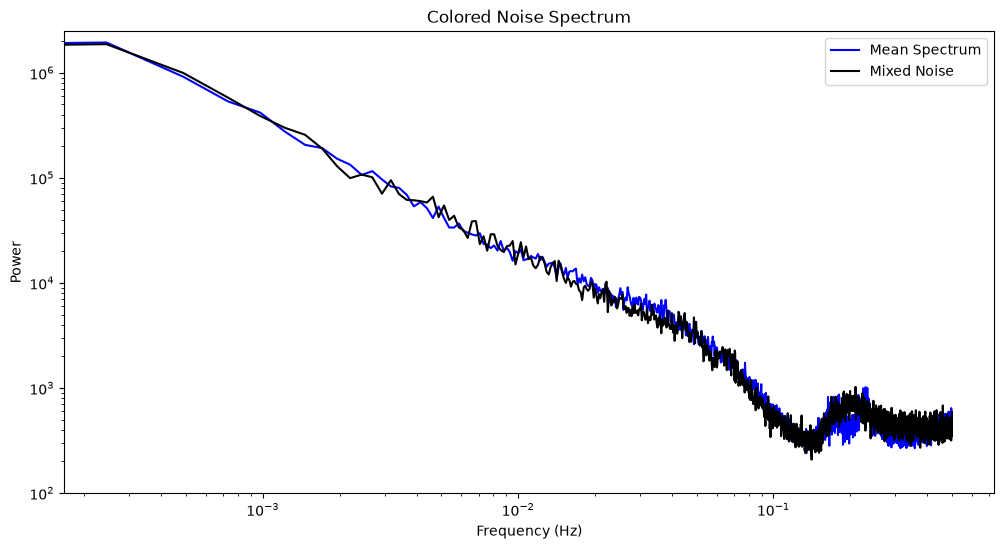

In [6]:
random_state = np.random.RandomState(2)

# --- FILTER USAGE ---
fs = 1
num_samples = int(1.5e+5)
white_noise = random_state.randn(num_samples)

# Design a filter for alpha = 1.5 (between pink and brown)
sos_pink = diseno_filtro_fraccionario(alpha=-slope_fcut0, fs=fs, num_etapas=8) # num_etapas=8
sos_brown = diseno_filtro_fraccionario(alpha=-slope_fcut1, fs=fs, num_etapas=6) # num_etapas=6

# Apply the IIR cascade quickly with SciPy
pink_noise = sosfilt(sos_pink, white_noise)
brown_noise = sosfilt(sos_brown, white_noise)

pink_psd = psd(pink_noise, window_size=4096)
brown_psd = psd(brown_noise, window_size=4096)

filter_type = 'butter'
minimum_attenuation = None  # dB
p_order = 5
ripple = None
Q = 3
b, a = iirfilter(p_order, fcut0, rp=ripple, rs=minimum_attenuation, btype='lowpass', analog=False, ftype=filter_type, output='ba', fs=1)
c, d = iirfilter(p_order, [fcut0, fcut1], rp=ripple, rs=minimum_attenuation, btype='bandpass', analog=False, ftype=filter_type, output='ba', fs=1)
e, f = iirfilter(p_order, fcut1, rp=ripple, rs=minimum_attenuation, btype='highpass', analog=False, ftype=filter_type, output='ba', fs=1)
g, h = iirpeak(fcut0-0.01, 2, fs=1) # raising attenuation at the end of pink noise band
m, n = iirpeak(fcut1, 5, fs=1) # raising attenuation at the beginning of white noise band

k, j = iirpeak(breathe_peak, Q, fs)


pink_noise_filtered = filtfilt(b, a, pink_noise)
brown_noise_filtered = filtfilt(9.5*c, d, brown_noise)
white_noise_filtered = filtfilt(0.009*e, f, white_noise)
peak_white_noise_filtered = filtfilt(0.005*k, j, white_noise)

mixed_noise_filtered = pink_noise_filtered + brown_noise_filtered + white_noise_filtered + peak_white_noise_filtered

peak_pink_noise_filtered = filtfilt(0.45*g, h, mixed_noise_filtered)
peak_brown_noise_filtered = filtfilt(0.5*m, n, mixed_noise_filtered)

mixed_noise_filtered =  peak_pink_noise_filtered + peak_brown_noise_filtered + mixed_noise_filtered

mixed_psd_filtered = psd(mixed_noise_filtered, window_size=4096)

plt.figure(figsize=(12, 6))
plt.loglog(freqs, mean_spectrum, label='Mean Spectrum', color='blue')
plt.loglog(freqs, mixed_psd_filtered, label='Mixed Noise', color='black')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.ylim(1e2, 0.25e7)
plt.title('Colored Noise Spectrum')
plt.legend()
plt.show()

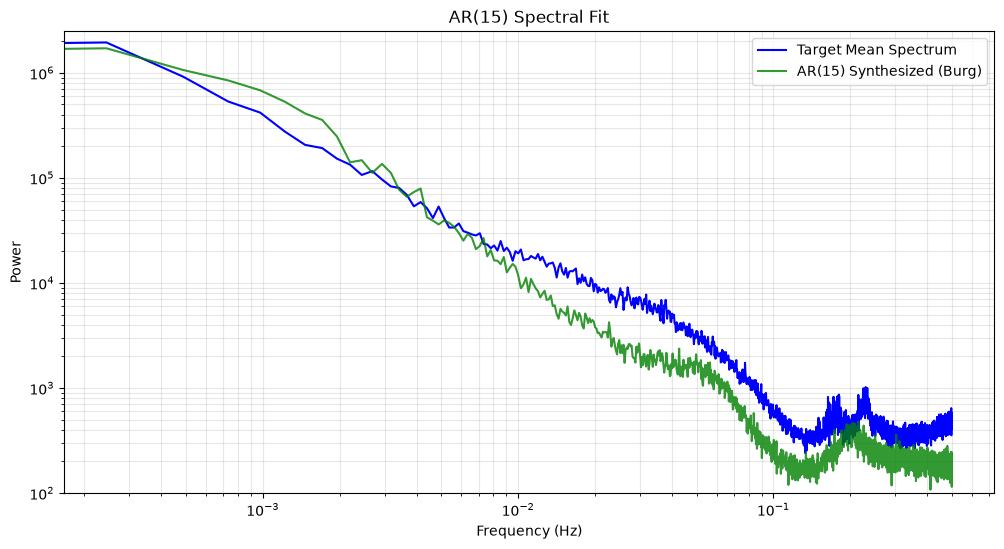

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.regression.linear_model import burg
from scipy.signal import lfilter

# 1. Normalize target synthetic signal
x = (mixed_noise_filtered - np.mean(mixed_noise_filtered)) / np.std(mixed_noise_filtered)

# 2. Fit AR Model (Burg method)
# Tip: Orders between 12 and 16 provide enough pole pairs for 1/f slope + 2 resonant peaks
ORDER = 15
phi_burg, sigma_burg = burg(x, order=ORDER)

# 3. Form denominator polynomial: A(z) = 1 - phi_1*z^-1 - ... - phi_p*z^-p
ar_denom = np.insert(-phi_burg, 0, 1.0)
ar_numer = [np.sqrt(sigma_burg)]

# 4. Synthesize colored noise using ONLY the driving innovation
# Do NOT add extra noise after lfilter!
white_noise = np.random.randn(len(x))
ar_synthesized = lfilter(ar_numer, ar_denom, white_noise)

# 5. Verify PSD
psd_filtered_signal = psd(ar_synthesized, window_size=4096)

plt.figure(figsize=(12, 6))
plt.loglog(freqs, mean_spectrum, label='Target Mean Spectrum', color='blue')
plt.loglog(freqs, psd_filtered_signal, label=f'AR({ORDER}) Synthesized (Burg)', color='green', alpha=0.8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.ylim(1e2, 0.25e7)
plt.title(f'AR({ORDER}) Spectral Fit')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

In [8]:
import scipy.linalg as linalg
from statsmodels.tsa.arima_process import ArmaProcess

class ExactARPacingPredictor:
    def __init__(self, phi, sigma_sq):
        """
        phi: AR coefficients [phi_1, ..., phi_p]
        sigma_sq: Innovation variance from Burg
        """
        self.phi = np.asarray(phi, dtype=np.float64)
        self.p = len(self.phi)
        self.sigma_sq = float(sigma_sq)

        # 1. Compute exact theoretical autocovariances gamma(0) ... gamma(p)
        # In ArmaProcess, AR polynomial is 1 - phi_1*z - phi_2*z^2 ...
        ar_poly = np.r_[1.0, -self.phi]
        ma_poly = np.r_[1.0]
        arma = ArmaProcess(ar_poly, ma_poly)
        
        # Theoretical autocorrelation rho(k)
        self.autocorr = arma.acf(lags=self.p + 1)
        # Theoretical autocovariance gamma(k)
        self.gamma = self.autocorr * (self.sigma_sq / (1.0 - np.dot(self.phi, self.autocorr[1:self.p + 1])))

    def _get_optimal_weights(self, N):
        """Solves exact MMSE linear predictor weights w and error variance for history length N."""
        k = min(N, self.p)
        
        if k == self.p:
            return self.phi, self.sigma_sq

        # Exact Yule-Walker solve for finite history N < p
        R_matrix = linalg.toeplitz(self.gamma[:k])
        r_vector = self.gamma[1:k + 1]
        
        weights = linalg.solve(R_matrix, r_vector)
        # Exact conditional error variance for finite sample size N
        pred_variance = self.gamma[0] - np.dot(weights, r_vector)
        
        return weights, max(pred_variance, self.sigma_sq)

    def forecast_next_rr(self, rr_history, rr_mean_ref, rr_std_ref, stochastic=False):
        """
        Forecasts exactly 1 step ahead (RR[n+1]) from 1 to 30 past RR intervals.
        """
        rr = np.asarray(rr_history, dtype=np.float64).flatten()
        N = len(rr)
        if N == 0:
            raise ValueError("History must contain at least 1 sample.")

        # Patient baseline anchor:
        # If history is long (>=10), use the patient's current operational mean to prevent drift.
        # If history is tiny (1 to 3 beats), smoothly blend toward the age reference.
        weight_local = min(N / 10.0, 1.0)
        local_mean = np.mean(rr)
        effective_mean = weight_local * local_mean + (1.0 - weight_local) * rr_mean_ref

        # Standardize using age-matched standard deviation (scale of variability)
        z = (rr - effective_mean) / (rr_std_ref + 1e-8)

        # Get exact weights and exact variance for this specific history length
        weights, pred_var = self._get_optimal_weights(N)
        k = len(weights)

        # Most recent beats ordered backwards: [z[n], z[n-1], ...]
        z_recent = z[-1 : -k - 1 : -1]

        # 1-step exact projection
        z_next = float(np.dot(weights, z_recent))

        # Pacing innovation with exact conditional variance
        if stochastic:
            z_next += np.random.normal(loc=0.0, scale=np.sqrt(pred_var))

        # Denormalize
        rr_next = (z_next * rr_std_ref) + effective_mean
        return float(rr_next)


predictor = ExactARPacingPredictor(phi=phi_burg, sigma_sq=sigma_burg)
# 3. Load subject data and age-based reference values
subject = 'nsr041RRcl'
subject_path = pathlib.Path(series_path) / f"{subject}.txt"
subject_serie = np.loadtxt(subject_path, dtype=float)
subject_age = get_age_years(subject, ages_table)
rr_mean_ref, rr_std_ref = get_rr_reference(subject_age)


# # 4. Take the last observed window (e.g., 30 samples, or as few as 1)
# v = 30
# history_window = subject_serie[-30]
# print(history_window)
# # 5. Forecast next RR interval (1 step ahead)
# next_rr_deterministic = predictor.forecast_next_rr(
#     history_window, rr_mean_ref, rr_std_ref, stochastic=False
# )

In [33]:
# extract random RR interval from the subject series for comparison
percent_extract = 0.9
# indexes for extraction
num_samples = len(subject_serie)
num_extract = int(num_samples * percent_extract)
rng = np.random.default_rng(7)

extract_indices = rng.choice(num_samples, size=num_extract, replace=False)
modified_subject_serie = np.copy(subject_serie)
modified_subject_serie[extract_indices] = np.nan  # Set extracted indices to NaN for comparison

window_size = 30

for i in range(len(subject_serie)):
    if i == 0 and np.isnan(modified_subject_serie[i]):
        modified_subject_serie[i] = rr_mean_ref  # Replace first NaN with mean reference
        continue
    elif np.isnan(modified_subject_serie[i]) and i <= window_size:
        # Use the last observed value for imputation
        next_rr_paced = predictor.forecast_next_rr(
            modified_subject_serie[:i], rr_mean_ref, rr_std_ref, stochastic=True
        )
        modified_subject_serie[i] = next_rr_paced
    elif np.isnan(modified_subject_serie[i]) and i > window_size:
        # Use the last 30 observed values for imputation
        next_rr_paced = predictor.forecast_next_rr(
            modified_subject_serie[i-window_size:i], rr_mean_ref, rr_std_ref, stochastic=False
        )
        modified_subject_serie[i] = next_rr_paced

In [27]:
print(modified_subject_serie[:35])

[839.9949491  802.92319116 832.7067064  861.14419314 840.94900096
 859.13613903 906.33404993 885.87614468 928.18243394 885.34827553
 881.53111079 918.81228776 905.53796067 811.95307582 817.48468023
 850.63358906 783.24341578 796.87687668 821.60668113 880.38348771
 835.04170102 788.91405634 862.96161736 938.56518146 884.39217505
 867.9654401  882.70253328 839.82686759 867.04814417 861.83198296
 841.00322053 867.         836.         848.07102128 852.17801662]


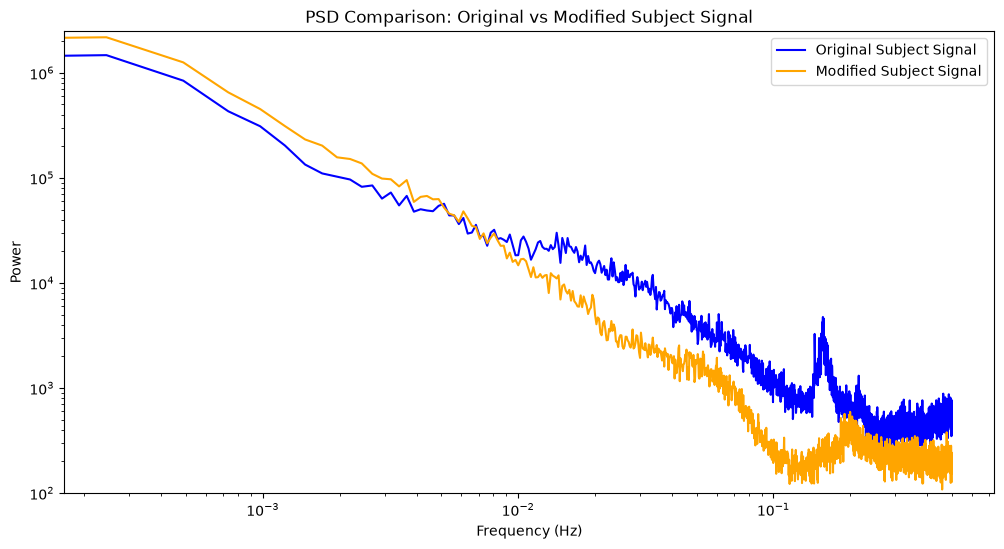

In [34]:
psd_modified_signal = psd(modified_subject_serie, window_size=4096)
psd_subject_signal = psd(subject_serie, window_size=4096)

plt.figure(figsize=(12, 6))
plt.loglog(freqs, psd_subject_signal, label='Original Subject Signal', color='blue')
plt.loglog(freqs, psd_modified_signal, label='Modified Subject Signal', color='orange')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.ylim(1e2, 0.25e7)
plt.title('PSD Comparison: Original vs Modified Subject Signal')
plt.legend()
plt.show()

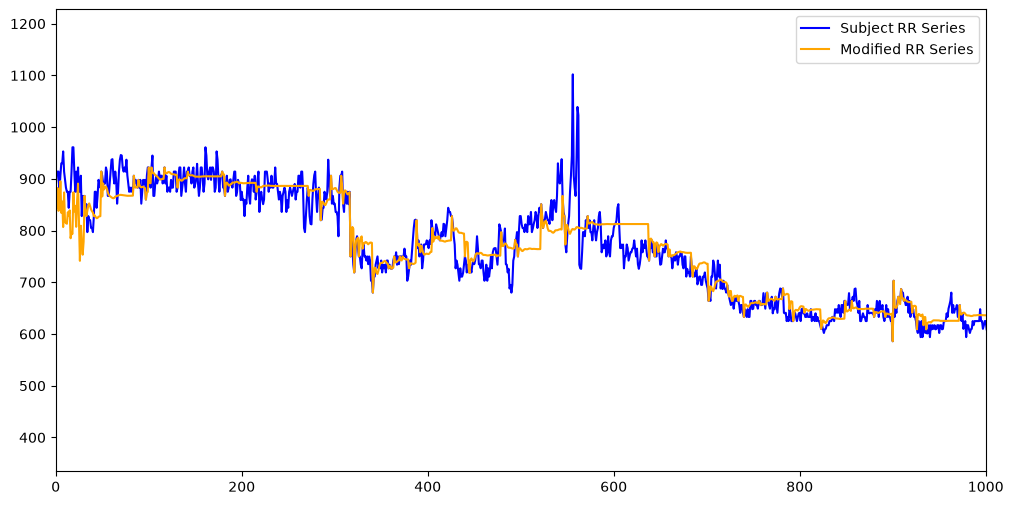

In [35]:
qq = 0
plt.figure(figsize=(12, 6))
plt.plot(subject_serie, label='Subject RR Series', color='blue')
plt.plot(modified_subject_serie, label='Modified RR Series', color='orange')
plt.xlim(qq, qq+1000)
plt.legend()
plt.show()

In [9]:
##################### ORDER = 5 ########################
phi_burg

array([ 0.42122775,  0.21888279,  0.17519924,  0.15477741,  0.05843703,
       -0.05126745, -0.0961932 , -0.05325267,  0.00965624,  0.04010668,
        0.03940572,  0.02326704,  0.01051167,  0.01193027,  0.02548546])

In [17]:
range_key = f"{start}-{end}"
ar_parameters_by_range = {
    range_key: {
        "phi_burg": phi_burg.tolist(),
        "sigma_burg": sigma_burg.tolist(),
        "order": ORDER,
    }
}

with open("ar_model_parameters.json", "w") as f:
    json.dump(ar_parameters_by_range, f, indent=4)